In [1]:
import sys
from pathlib import Path
import os

import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator


In [2]:
# Me aseguro de que el directorio raíz del proyecto esté en el sys.path
project_root = Path(os.path.abspath("")).parent

# Añado el directorio raíz al sys.path si no está ya presente
if project_root not in sys.path:
    sys.path.append(str(project_root))

In [3]:
from src.config import processed_data_dir, models_dir, reports_dir, load_config


Current working directory: /home/jorge/development/ImageReconstructionDL/notebooks
Loading configuration from /home/jorge/development/ImageReconstructionDL/src/config.yaml


In [4]:
# Cargo la configuración 
config = load_config()

Loading configuration from /home/jorge/development/ImageReconstructionDL/src/config.yaml


In [5]:
# Inicializar TensorBoard
nombre_modelo = 'convolutional_autoencoder_model_optuna_2'
log_dir = reports_dir() / "logs"/ nombre_modelo

In [6]:
# Función para cargar los datos de un tag específico desde los logs de TensorBoard
def load_tensorboard_logs(log_dir, base_tag):
    all_steps = []
    all_values = []

    # Recorremos todos los directorios de los trials
    for trial_dir in os.listdir(log_dir):
        trial_path = os.path.join(log_dir, trial_dir)

        # Verificamos si es un directorio y contiene eventos
        if os.path.isdir(trial_path):
            trial_id = trial_dir  # trial_id sería algo como 'trial_0', 'trial_1', etc.
            trial_tag = f"{trial_id}/{base_tag}"  # Crear el tag completo, por ejemplo, 'trial_0/Loss/val'

            for subdir, dirs, files in os.walk(trial_path):
                for file in files:
                    if file.startswith("events.out.tfevents"):
                        event_file = os.path.join(subdir, file)
                        event_acc = EventAccumulator(event_file)
                        event_acc.Reload()

                        # Verificamos si el tag con el identificador del trial está presente
                        if trial_tag in event_acc.Tags()['scalars']:
                            events = event_acc.Scalars(trial_tag)
                            steps = [e.step for e in events]
                            values = [e.value for e in events]

                            # Almacenar los pasos y valores
                            all_steps.append(steps)
                            all_values.append(values)

    return all_steps, all_values

In [7]:
# Elige el base_tag que deseas graficar, por ejemplo, 'Loss/val'
base_tag_to_plot = 'val/PSNR'

In [8]:
# Cargar los logs
steps, values = load_tensorboard_logs(log_dir, base_tag_to_plot)

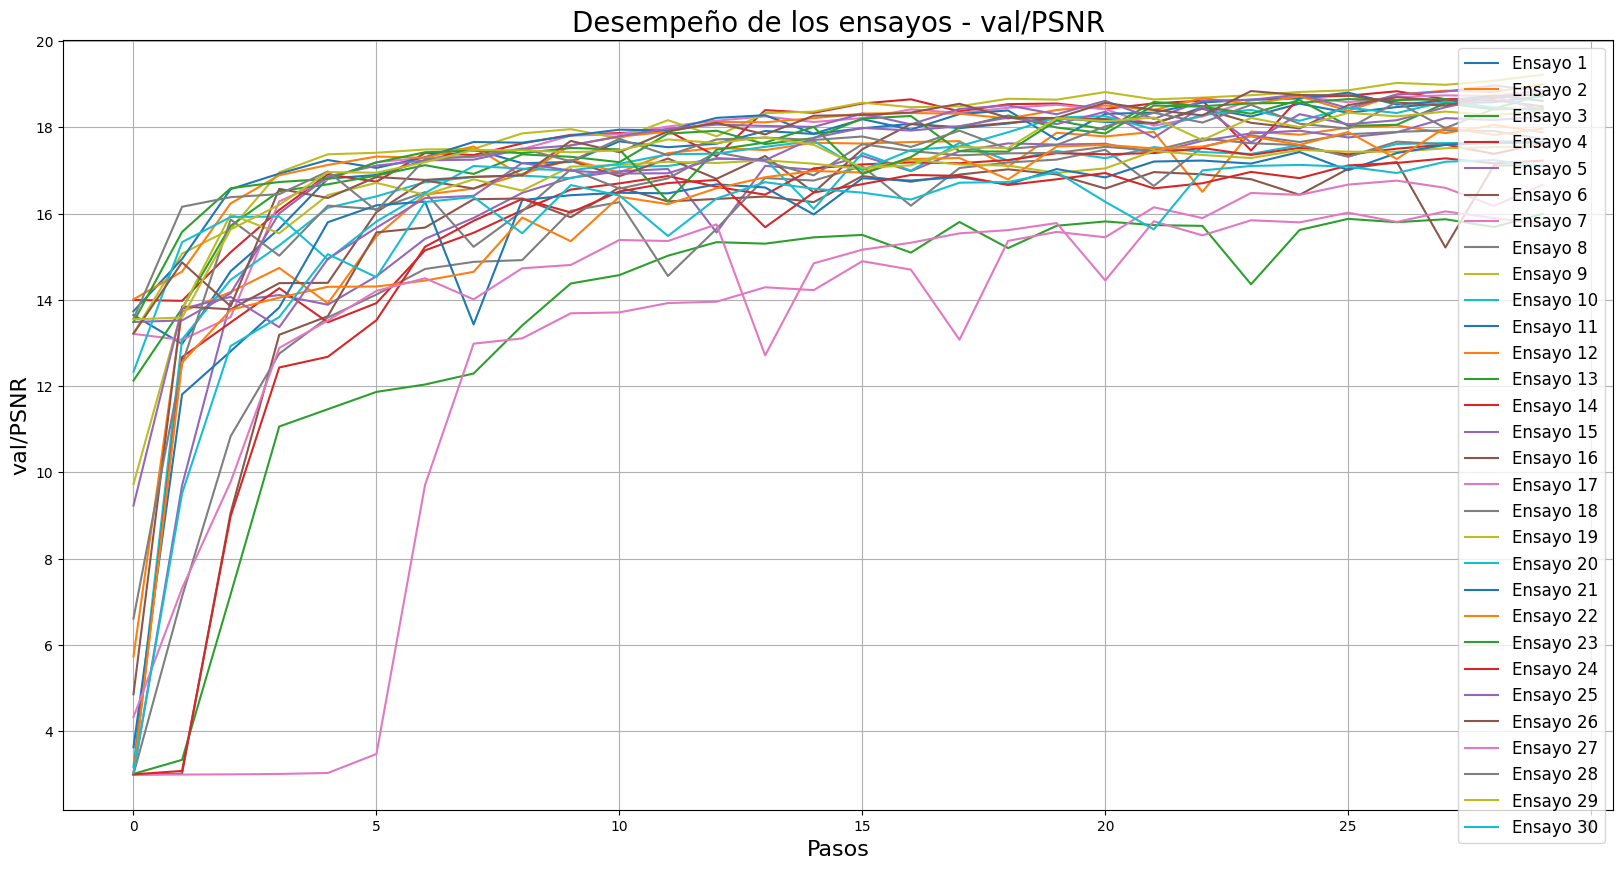

In [9]:
# Crear la figura de tamaño grande
plt.figure(figsize=(20, 10))  # Tamaño en pulgadas (ancho, alto)

# Graficar todos los trials para el base_tag elegido
for i, (step, value) in enumerate(zip(steps, values)):
    plt.plot(step, value, label=f'Ensayo {i + 1}')

plt.xlabel("Pasos", fontsize=16)
plt.ylabel(base_tag_to_plot, fontsize=16)
#plt.title(f"Performance of Trials - {base_tag_to_plot}", fontsize=20)
plt.title(f"Desempeño de los ensayos - {base_tag_to_plot}", fontsize=20)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True)  # Agregar una cuadrícula si lo deseas
plt.show()

In [10]:
# Elige el base_tag que deseas graficar, por ejemplo, 'Loss/val'
base_tag_to_plot = 'val/SSIM'

In [11]:
# Cargar los logs
steps, values = load_tensorboard_logs(log_dir, base_tag_to_plot)

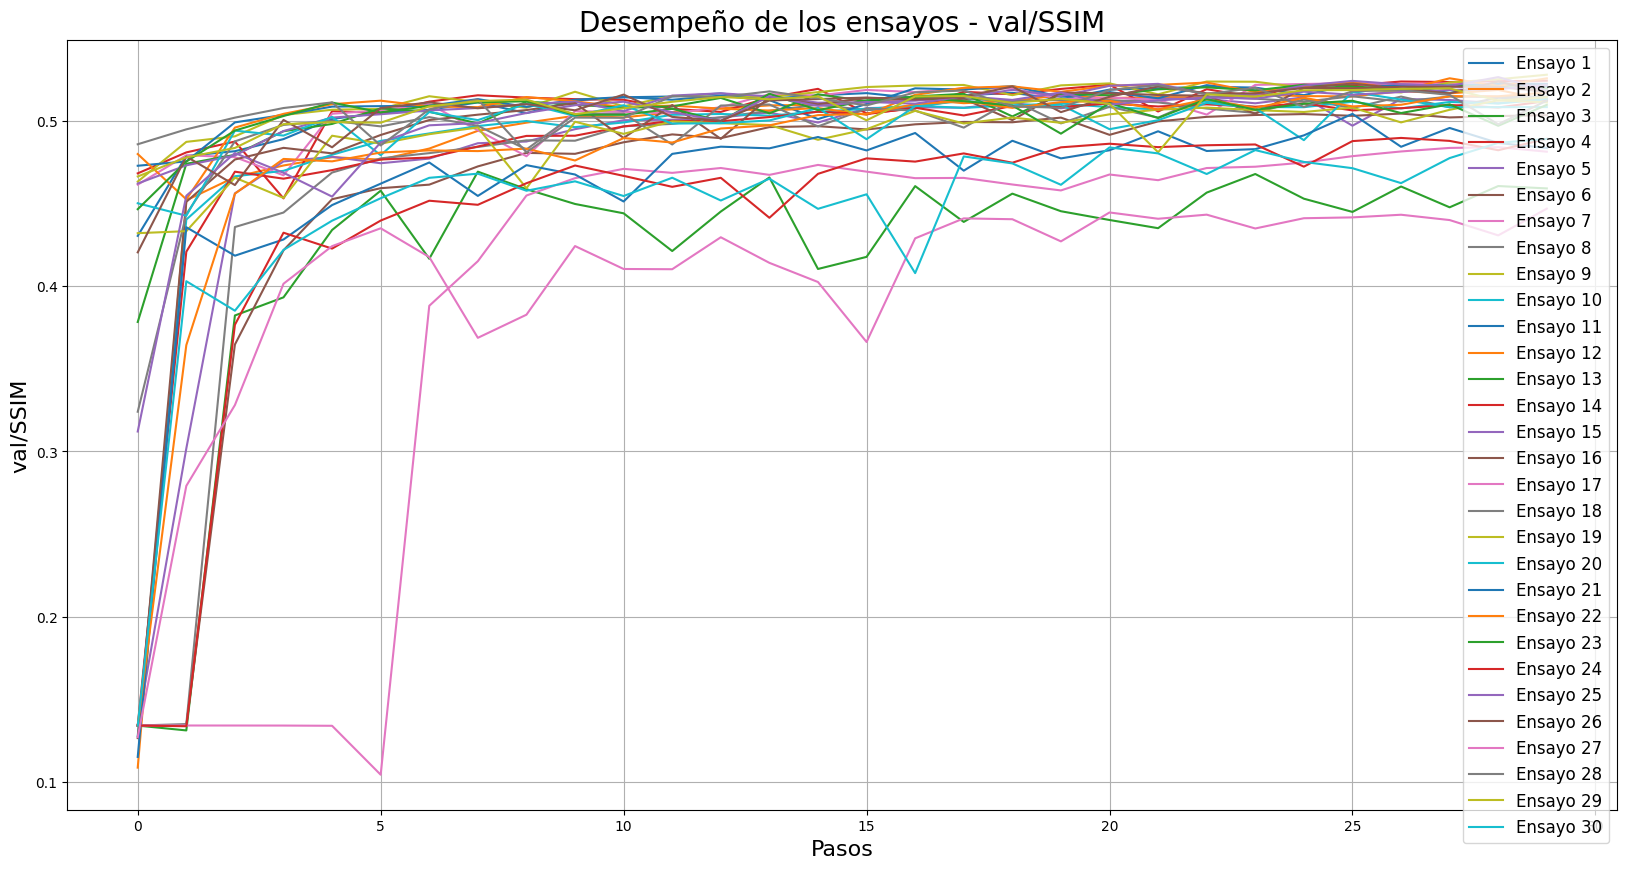

In [12]:
# Crear la figura de tamaño grande
plt.figure(figsize=(20, 10))  # Tamaño en pulgadas (ancho, alto)

# Graficar todos los trials para el base_tag elegido
for i, (step, value) in enumerate(zip(steps, values)):
    plt.plot(step, value, label=f'Ensayo {i + 1}')

plt.xlabel("Pasos", fontsize=16)
plt.ylabel(base_tag_to_plot, fontsize=16)
#plt.title(f"Performance of Trials - {base_tag_to_plot}", fontsize=20)
plt.title(f"Desempeño de los ensayos - {base_tag_to_plot}", fontsize=20)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True)  # Agregar una cuadrícula si lo deseas
plt.show()

In [13]:
# Elige el base_tag que deseas graficar, por ejemplo, 'Loss/val'
base_tag_to_plot = 'val/Compression_Ratio'


In [14]:
# Cargar los logs
steps, values = load_tensorboard_logs(log_dir, base_tag_to_plot)

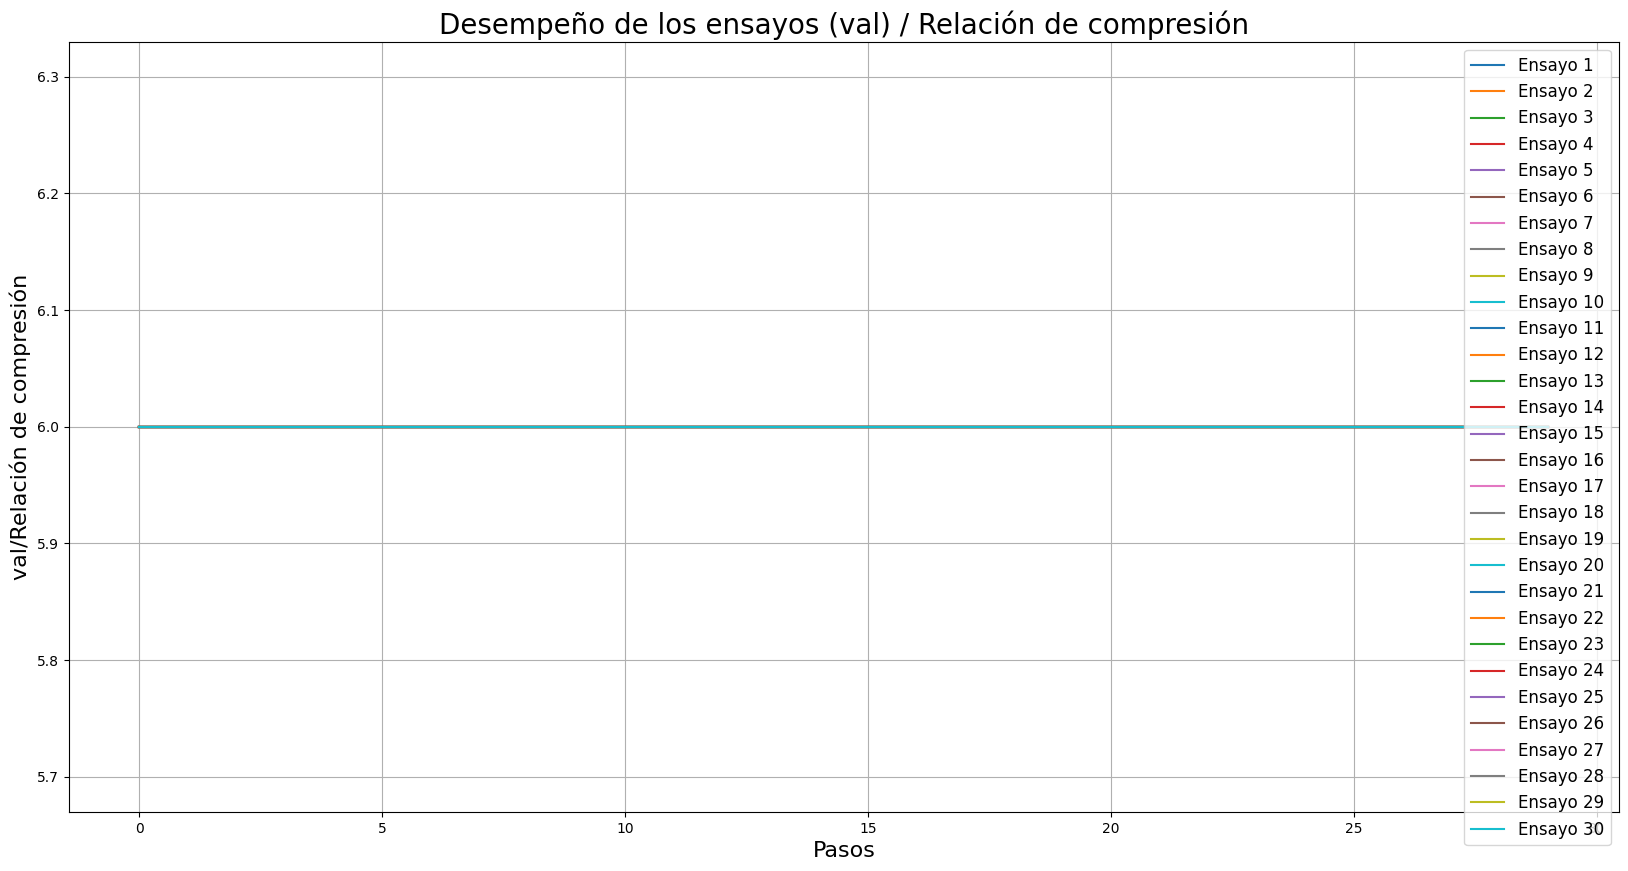

In [15]:
# Crear la figura de tamaño grande
plt.figure(figsize=(20, 10))  # Tamaño en pulgadas (ancho, alto)

# Graficar todos los trials para el base_tag elegido
for i, (step, value) in enumerate(zip(steps, values)):
    plt.plot(step, value, label=f'Ensayo {i + 1}')

plt.xlabel("Pasos", fontsize=16)
#plt.ylabel(base_tag_to_plot, fontsize=16)
plt.ylabel("val/Relación de compresión", fontsize=16)
#plt.title(f"Performance of Trials - {base_tag_to_plot}", fontsize=20)
plt.title(f"Desempeño de los ensayos (val) / Relación de compresión", fontsize=20)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True)  # Agregar una cuadrícula si lo deseas
plt.show()